In [69]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

## Load Dataset

In [70]:
data_root = "/kaggle/input/datasets/menahilahmad/smogdetection/SmogDetection-master"

clear_path = "/kaggle/input/datasets/menahilahmad/smogdetection/SmogDetection-master/Clear"
smog_path = "/kaggle/input/datasets/menahilahmad/smogdetection/SmogDetection-master/Smog"

In [71]:
clear_images = [os.path.join(clear_path, f) for f in os.listdir(clear_path) if f.endswith(('.JPG'))]
smog_images = [os.path.join(smog_path, f) for f in os.listdir(smog_path) if f.endswith(('.JPG'))]

print(f"Clear images: {len(clear_images)}")
print(f"Smog images: {len(smog_images)}")

Clear images: 93
Smog images: 107


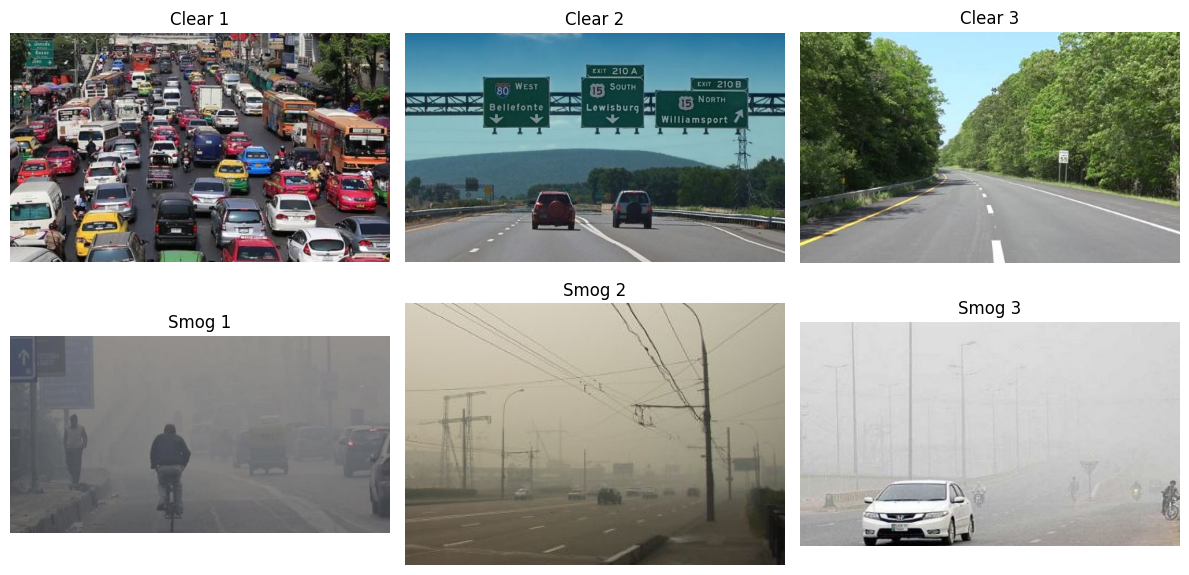

Total: 93 clear, 107 smoggy images


In [72]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

def visualize_samples(clear_images, smog_images, n=3):
    """
    Display n clear and n smoggy images side by side.
    """
    
    # Random sample
    random_clears = random.sample(clear_images, n)
    random_smogs = random.sample(smog_images, n)
    
    # Display
    fig, axes = plt.subplots(2, n, figsize=(4*n, 6))
    
    for i, img_path in enumerate(random_clears):
        img = Image.open(img_path)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Clear {i+1}")
        axes[0, i].axis('off')
    
    for i, img_path in enumerate(random_smogs):
        img = Image.open(img_path)
        axes[1, i].imshow(img)
        axes[1, i].set_title(f"Smog {i+1}")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total: {len(clear_images)} clear, {len(smog_images)} smoggy images")

# Usage
visualize_samples(clear_images, smog_images, n=3)

In [73]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = ImageFolder(root=data_root, transform=transform)
print(f"Classes: {dataset.class_to_idx}")
print(f"Total images: {len(dataset)}")

Classes: {'Clear': 0, 'Smog': 1}
Total images: 200


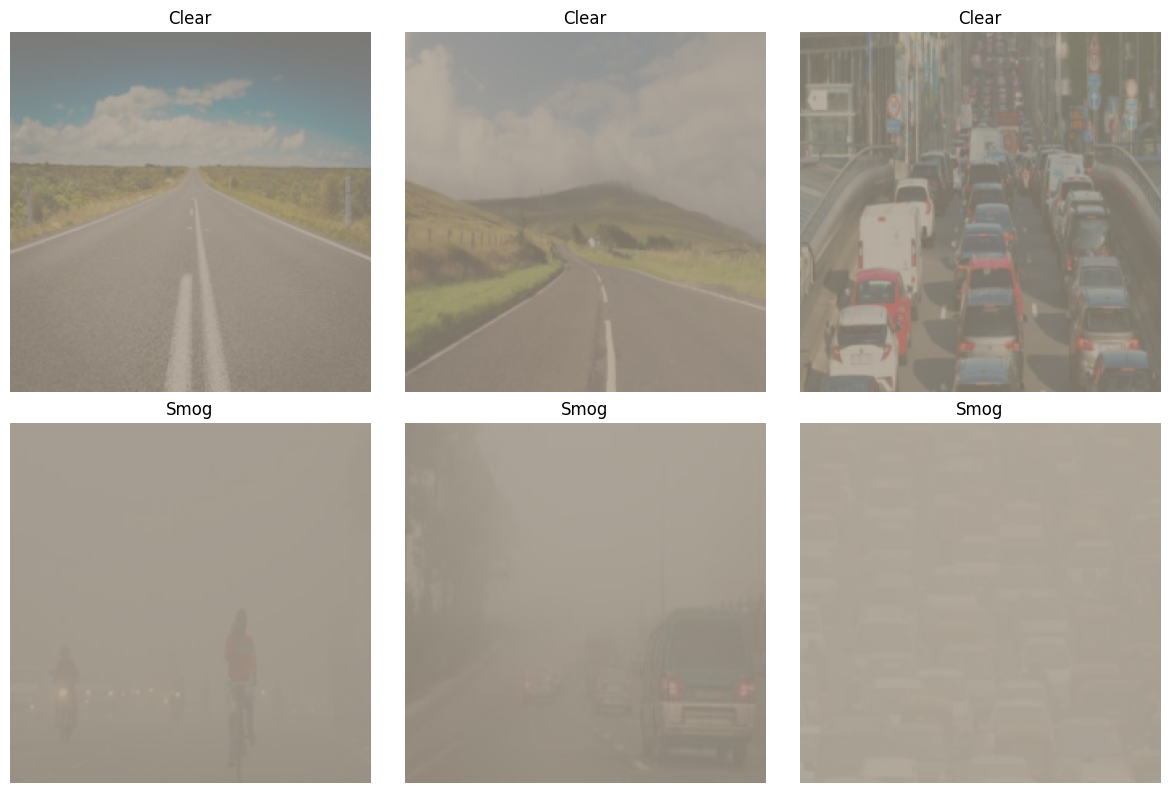

In [74]:
def visualize_transformed_dataset(dataset, num_clear=3, num_smog=3):
    """
    Visualize random clear and smog images after transforms.
    """
    
    # Get indices for each class
    clear_indices = [i for i, (_, label) in enumerate(dataset) if label == 0]
    smog_indices = [i for i, (_, label) in enumerate(dataset) if label == 1]
    
    # Random sample
    random_clear = random.sample(clear_indices, num_clear)
    random_smog = random.sample(smog_indices, num_smog)
    
    # Display
    fig, axes = plt.subplots(2, max(num_clear, num_smog), figsize=(4*max(num_clear, num_smog), 8))
    
    for i, idx in enumerate(random_clear):
        image, label = dataset[idx]
        
        # Denormalize
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = image * std + mean
        image = torch.clamp(image, 0, 1)
        
        image_np = image.numpy().transpose(1, 2, 0)
        axes[0, i].imshow(image_np)
        axes[0, i].set_title("Clear")
        axes[0, i].axis('off')
    
    for i, idx in enumerate(random_smog):
        image, label = dataset[idx]
        
        # Denormalize
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = image * std + mean
        image = torch.clamp(image, 0, 1)
        
        image_np = image.numpy().transpose(1, 2, 0)
        axes[1, i].imshow(image_np)
        axes[1, i].set_title("Smog")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()


visualize_transformed_dataset(dataset, num_clear=3, num_smog=3)

In [75]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision.datasets import ImageFolder

# 1. AGGRESSIVE AUGMENTATION
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=15, translate=(0.15, 0.15), scale=(0.8, 1.2)),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

temp_dataset = ImageFolder(root=data_root)

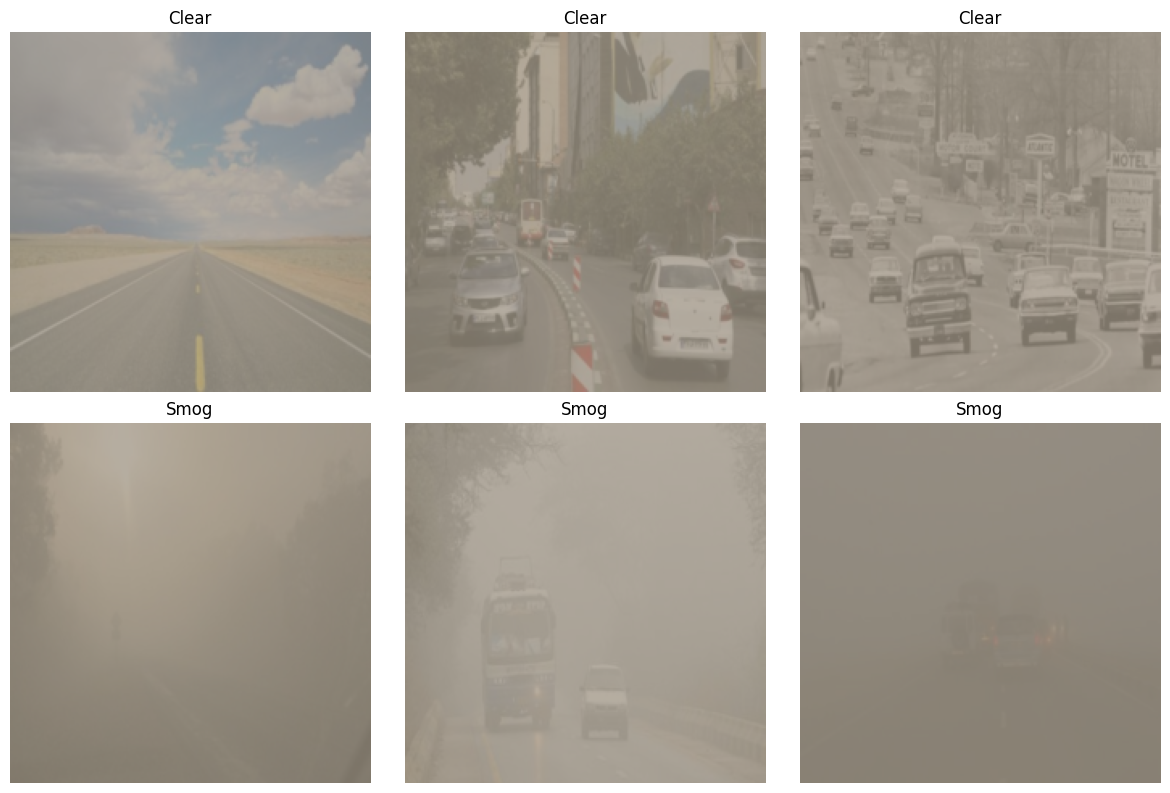

In [76]:
def visualize_transformed_dataset(dataset, num_clear=3, num_smog=3):
    """
    Visualize random clear and smog images after transforms.
    """
    
    # Get indices for each class
    clear_indices = [i for i, (_, label) in enumerate(dataset) if label == 0]
    smog_indices = [i for i, (_, label) in enumerate(dataset) if label == 1]
    
    # Random sample
    random_clear = random.sample(clear_indices, num_clear)
    random_smog = random.sample(smog_indices, num_smog)
    
    # Display
    fig, axes = plt.subplots(2, max(num_clear, num_smog), figsize=(4*max(num_clear, num_smog), 8))
    
    for i, idx in enumerate(random_clear):
        image, label = dataset[idx]
        
        # Denormalize
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = image * std + mean
        image = torch.clamp(image, 0, 1)
        
        image_np = image.numpy().transpose(1, 2, 0)
        axes[0, i].imshow(image_np)
        axes[0, i].set_title("Clear")
        axes[0, i].axis('off')
    
    for i, idx in enumerate(random_smog):
        image, label = dataset[idx]
        
        # Denormalize
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = image * std + mean
        image = torch.clamp(image, 0, 1)
        
        image_np = image.numpy().transpose(1, 2, 0)
        axes[1, i].imshow(image_np)
        axes[1, i].set_title("Smog")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()


visualize_transformed_dataset(dataset, num_clear=3, num_smog=3)

In [77]:
# Split indices
train_size = int(0.8 * len(temp_dataset))
val_size = len(temp_dataset) - train_size
train_indices, val_indices = random_split(temp_dataset, [train_size, val_size])
train_idx = train_indices.indices
val_idx = val_indices.indices

# Now create datasets with DIFFERENT transforms using those indices
train_dataset = Subset(
    ImageFolder(root=data_root, transform=transform_train), 
    train_idx
)
val_dataset = Subset(
    ImageFolder(root=data_root, transform=transform_val), 
    val_idx
)

In [78]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images")

Train: 160 images
Val: 40 images


In [79]:
images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")
print(f"Batch labels: {labels}")

Batch images shape: torch.Size([16, 3, 224, 224])
Batch labels: tensor([1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1])


In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


In [81]:
import torch
import torch.nn as nn
from torchvision import models


# Create fresh model on CPU first
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)


# Freeze early layers (they already know edges/textures)
for param in model.parameters():
    param.requires_grad = False

# Only train the final few layers
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

# Replace with stronger regularization
model.fc = nn.Sequential(
    nn.Dropout(0.6),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 1)
)

model.fc = nn.Linear(512, 1)

model = model.to(device)

## Training

In [82]:
def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    train_loss, train_acc = 0, 0
    
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        y = y.float().view(-1, 1)
        
        y_pred = model(X)  # Already has sigmoid
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accuracy (no sigmoid needed)
        pred_class = (y_pred > 0.5).float()
        train_acc += (pred_class == y).sum().item() / len(y_pred)
    
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc

def test_step(model, dataloader, loss_fn, device):
    model.eval()
    test_loss, test_acc = 0, 0
    
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y = y.float().view(-1, 1)
            
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            test_loss += loss.item()
            
            pred_class = (y_pred > 0.5).float()
            test_acc += (pred_class == y).sum().item() / len(y_pred)
    
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    return test_loss, test_acc

In [83]:
from tqdm.auto import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau


def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, device, epochs=10):
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
    
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)

        scheduler.step(test_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f"Epoch: {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")
        
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
    
    return results

In [84]:
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

In [85]:
# Run training
results = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=10
)

Epoch: 1 | train_loss: 0.6681 | train_acc: 0.4750 | test_loss: 0.6475 | test_acc: 0.4792
Epoch: 2 | train_loss: 0.5853 | train_acc: 0.5625 | test_loss: 0.5527 | test_acc: 0.4792
Epoch: 3 | train_loss: 0.5121 | train_acc: 0.7063 | test_loss: 0.4988 | test_acc: 0.5208
Epoch: 4 | train_loss: 0.4756 | train_acc: 0.7375 | test_loss: 0.4432 | test_acc: 0.5625
Epoch: 5 | train_loss: 0.4372 | train_acc: 0.7438 | test_loss: 0.4022 | test_acc: 0.6250
Epoch: 6 | train_loss: 0.3976 | train_acc: 0.8000 | test_loss: 0.3695 | test_acc: 0.7292
Epoch: 7 | train_loss: 0.3680 | train_acc: 0.8500 | test_loss: 0.3383 | test_acc: 0.7292
Epoch: 8 | train_loss: 0.3436 | train_acc: 0.8313 | test_loss: 0.3103 | test_acc: 0.7917
Epoch: 9 | train_loss: 0.3130 | train_acc: 0.8750 | test_loss: 0.2960 | test_acc: 0.7917
Epoch: 10 | train_loss: 0.3128 | train_acc: 0.8375 | test_loss: 0.2704 | test_acc: 0.8125


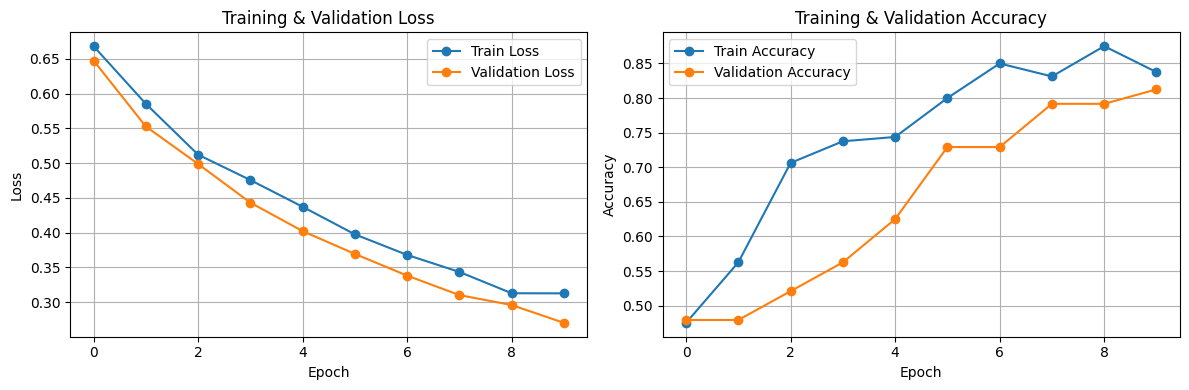

In [86]:
import matplotlib.pyplot as plt

def plot_results(results):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot losses
    ax1.plot(results["train_loss"], label="Train Loss", marker='o')
    ax1.plot(results["test_loss"], label="Validation Loss", marker='o')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Training & Validation Loss")
    ax1.legend()
    ax1.grid(True)
    
    # Plot accuracies
    ax2.plot(results["train_acc"], label="Train Accuracy", marker='o')
    ax2.plot(results["test_acc"], label="Validation Accuracy", marker='o')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Training & Validation Accuracy")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Call after training
plot_results(results)

In [87]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

test_path = "/kaggle/input/datasets/menahilahmad/test-traffic/test-traffic"

# Check if it exists and has subfolders
print("Contents:", os.listdir(test_path))
print("Subfolders:", [f for f in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, f))])

# Transform
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load test dataset
test_dataset = datasets.ImageFolder(root=test_path, transform=transform_test)

print(f"\nClasses: {test_dataset.class_to_idx}")
print(f"Total test images: {len(test_dataset)}")

# Count per class
clear_count = sum(1 for _, label in test_dataset if label == 0)
smog_count = sum(1 for _, label in test_dataset if label == 1)
print(f"Clear images: {clear_count}")
print(f"Smog images: {smog_count}")

# Create DataLoader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Contents: ['clear', 'smog']
Subfolders: ['clear', 'smog']

Classes: {'clear': 0, 'smog': 1}
Total test images: 20
Clear images: 10
Smog images: 10


In [96]:
def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y = y.float().view(-1, 1)
            
            output = model(X)
            prob = torch.sigmoid(output)
            pred = (prob > 0.5).float()
            
            correct += (pred == y).sum().item()
            total += len(y)
            
            all_preds.extend(pred.cpu().numpy().flatten())
            all_labels.extend(y.cpu().numpy().flatten())
    
    accuracy = correct / total
    return accuracy, all_preds, all_labels

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Evaluate on VALIDATION set
def get_metrics(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y = y.float().view(-1, 1)
            
            output = model(X)
            prob = torch.sigmoid(output)
            pred = (prob > 0.5).float()
            
            all_preds.extend(pred.cpu().numpy().flatten())
            all_labels.extend(y.cpu().numpy().flatten())
            all_probs.extend(prob.cpu().numpy().flatten())
    
    # Calculate metrics
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }


In [99]:
# Run evaluation on VALIDATION set
val_metrics = get_metrics(model, val_loader, device)

print(f"\n Validation Set Metrics:")
print(f"   Precision: {val_metrics['precision']:.4f}")
print(f"   Recall:    {val_metrics['recall']:.4f}")
print(f"   F1 Score:  {val_metrics['f1']:.4f}")


 Validation Set Metrics:
   Precision: 1.0000
   Recall:    0.7619
   F1 Score:  0.8649


In [100]:
# Classification Report
print("\n--- Validation Classification Report ---")
print(classification_report(val_metrics['labels'], val_metrics['predictions'], 
                            target_names=class_names))


--- Validation Classification Report ---
              precision    recall  f1-score   support

       clear       0.79      1.00      0.88        19
        smog       1.00      0.76      0.86        21

    accuracy                           0.88        40
   macro avg       0.90      0.88      0.87        40
weighted avg       0.90      0.88      0.87        40



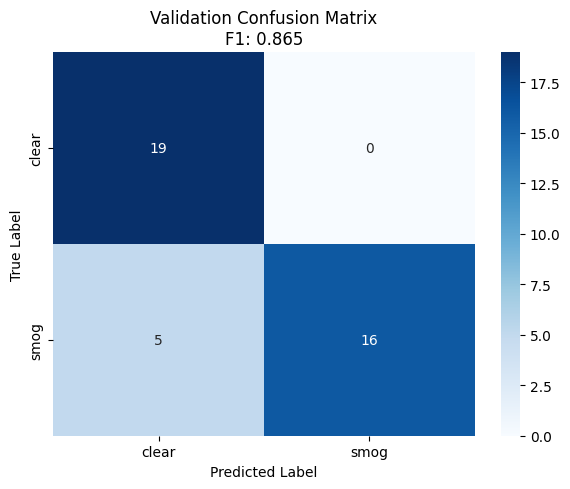

In [101]:
# Confusion Matrix
cm = confusion_matrix(val_metrics['labels'], val_metrics['predictions'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Validation Confusion Matrix\nF1: {val_metrics["f1"]:.3f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [97]:
# Evaluate
test_accuracy, predictions, ground_truth = evaluate(model, test_loader, device)
print(f"\n Test Accuracy (small set of images): {test_accuracy:.4f} ({test_accuracy:.2%})")


 Test Accuracy (small set of images): 0.8500 (85.00%)


In [89]:
class_names = test_dataset.classes

In [91]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Evaluate on test set
def get_metrics(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            y = y.float().view(-1, 1)
            
            output = model(X)
            prob = torch.sigmoid(output)
            pred = (prob > 0.5).float()
            
            all_preds.extend(pred.cpu().numpy().flatten())
            all_labels.extend(y.cpu().numpy().flatten())
            all_probs.extend(prob.cpu().numpy().flatten())
    
    # Calculate metrics
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

# Run evaluation
metrics = get_metrics(model, test_loader, device)

print(f" Test Set Metrics:")
print(f"   Precision: {metrics['precision']:.4f}")
print(f"   Recall:    {metrics['recall']:.4f}")
print(f"   F1 Score:  {metrics['f1']:.4f}")

 Test Set Metrics:
   Precision: 1.0000
   Recall:    0.7000
   F1 Score:  0.8235


In [92]:
from sklearn.metrics import classification_report

# Get class names
class_names = test_dataset.classes  # ['clear', 'smog'] or similar

print("\n--- Detailed Classification Report ---")
print(classification_report(metrics['labels'], metrics['predictions'], 
                            target_names=class_names))


--- Detailed Classification Report ---
              precision    recall  f1-score   support

       clear       0.77      1.00      0.87        10
        smog       1.00      0.70      0.82        10

    accuracy                           0.85        20
   macro avg       0.88      0.85      0.85        20
weighted avg       0.88      0.85      0.85        20



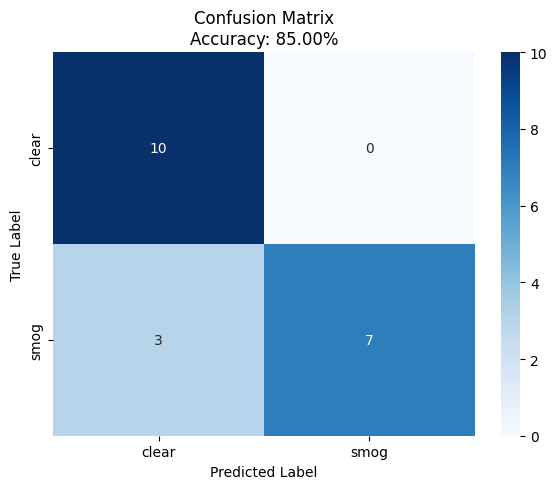

In [90]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Confusion Matrix Heatmap
cm = confusion_matrix(ground_truth, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix\nAccuracy: {test_accuracy:.2%}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [93]:
# Save model
torch.save(model.state_dict(), "smog_classifier_traffic.pth")

In [94]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load with Linear layer (no Sigmoid)
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 1)  # Simple Linear
model.load_state_dict(torch.load("smog_classifier_traffic.pth", map_location='cpu'))
model = model.to(device)
model.eval()

print(" Model loaded successfully!")

 Model loaded successfully!


In [95]:
model.eval()
with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device)
        output = model(X)
        print(f"Raw output (logits): {output[:5].flatten()}")
        print(f"After sigmoid: {torch.sigmoid(output[:5]).flatten()}")
        print(f"True labels: {y[:5]}")
        break

Raw output (logits): tensor([-1.4855,  0.7107,  0.6055, -1.9987, -2.0255], device='cuda:0')
After sigmoid: tensor([0.1846, 0.6706, 0.6469, 0.1193, 0.1166], device='cuda:0')
True labels: tensor([0, 1, 1, 0, 0])
